# Introduction to fMRI data in python

---



[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/alanturin-g/Computational_Neuroscience_UNITO_2026/blob/main/Borriero_1_neuroimaging_data_intro.ipynb)

In [ ]:
from google.colab import auth; auth.authenticate_user()
from google.colab import drive; drive.mount('/content/drive')

 # Import

In [ ]:
# Install the required libraries
! pip install nibabel nilearn nitime

In [ ]:
# import sys
# sys.version

In [3]:
import numpy as np
import nibabel as nib # For data import and handling
import nilearn as nil # For plotting and analysis
from nilearn import plotting
import nitime # For time series analysis
import matplotlib.pyplot as plt
from nilearn import plotting, surface, datasets
import pandas as pd
from nilearn.image import smooth_img
from nilearn.signal import clean
from tqdm import tqdm


 # Download some files

In [ ]:
# A wrapper method to download files

import os, subprocess, shlex
import os
import subprocess

def download_from_drive(file_keyword, base_folder="."):
    file_name, file_ID = files_dict[file_keyword]
    DEST_PATH = os.path.join(base_folder, file_name)
    if not os.path.exists(DEST_PATH):
        URL = f"https://drive.usercontent.google.com/download?id={file_ID}&confirm=t"
        cmd = ["wget", "-q", "--show-progress", "--progress=bar:force:noscroll",
            "--no-check-certificate", "-O", DEST_PATH, URL]
        ret = subprocess.call(cmd)  # shell=False by default
        if ret != 0:
            raise RuntimeError("Download failed. Check sharing settings or FILE_ID.")
        else:
            print("Downloaded " + file_name + "!")
    else:
        print(file_name + " already present:", DEST_PATH)


In [ ]:
files_dict = {'glasser_labels' : ('glasser_labels.csv','12LumqrRkp1rUAJGg8h3tOIwWubhyyoqY'),
              'glasser_atlas':   ('glasser_atlas.nii.gz','1GeB5pi25SRnyit8s5siDUCFFmJfsB3Yw'),
              'schaefer_labels': ('schaefer_labels.csv', '1Lgh4X9hud2xXGxYEWADFxfMe81P_tTfS'),
              'schaefer_atlas':  ('schaefer_atlas.nii.gz', '1acSTf6m9TyJxm2ruTcwd9eC8PNGfG1PX'),
              'subj_zero_rest':  ('subj_zero_rest.nii.gz', '1XXhVrMymlaBE0ekbgbHoH8fVYteWFGIa')}

In [ ]:
for key in files_dict.keys():
  download_from_drive(key)

# Load fMRI data

In [ ]:
# Load a fMRI volume from a file
"""""
The fMRI data are provided in the so-called nifti image format, identified by the extension .nii.
The extension .gz means that the file is compressed.
Inside the .nii.gz file there is the fMRI volume and a header file

"""""
main_path = '/content/'
file_name = 'subj_zero_rest.nii.gz'
data_ = nib.load(main_path+file_name) # Raw data in nifti image format


In [6]:
data = data_.get_fdata() # To extract the fMRI in numpy format
header = data_.header
affine = data_.affine

In [7]:
print(data.shape)

(60, 72, 60, 286)


The NIFTI header contains key information about the data stored in the file. Here's the explanation of the most important fields of the header.

- sizeof_hdr: It's the size of the header in bytes (It's always 348 bytes)
- datatype: Data type of the stored values
- bitpix: Space occupied by each value of the volume
- dim[0]: Number of dimensions of the volume
- dim[1:4]: Number of voxels along the three spatial dimensions
- dim[4]: Number of time points
- dim[5:8]: Additional dimensions, often unused
- pixdim[1:4]: Spatial sampling intervals: number of mm along each spatial axis
- pixdim[4]: Time repetition (TR): the time spacing between to consecutive volume (time points) 
- s_row: Rows of the affine matrix

In [9]:
print(header) # It contains general information about data and acquisition

<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  4  60  72  60 286   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float64
bitpix          : 64
slice_start     : 0
pixdim          : [-1.   3.   3.   3.   2.1  0.   0.   0. ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 2
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b''
aux_file        : b''
qform_code      : scanner
sform_code      : scanner
quatern_b       : -0.0
quatern_c       : 1.0
quatern_d       : 0.0
qoffset_x       : 90.0
qoffset_y       : -126.0
qoffset_z       : -72.0
srow_x          : [-3. -0.  0. 

In [11]:
affine

array([[  -3.,   -0.,    0.,   90.],
       [  -0.,    3.,   -0., -126.],
       [   0.,    0.,    3.,  -72.],
       [   0.,    0.,    0.,    1.]])

The affine matrix allow to transform the spatial indices to coordinates in the pysical spaces (in mm) \
 \
$\begin{bmatrix}
x \\ y \\ z \\ 1
\end{bmatrix}$
$=$
$\begin{bmatrix}
-3 & 0 & 0 & 90 \\
0 & 3 & 0 & -126 \\
0 & 0 & 3 & -72 \\
0 & 0 & 0 & 1 \\
\end{bmatrix}$
$ \begin{bmatrix}
i \\ j \\ k \\ 1
\end{bmatrix}$


In [13]:
data.shape # The data are shaped (x,y,z,t); x, left to right; y, posterior to anterior; z, inferior to superior

(60, 72, 60, 286)

In [12]:
# Get TR (time repetition)
TR = header.get_zooms()[3]
print(f"TR = {TR} seconds")

TR = 2.0999999046325684 seconds


# A first look to fMRI data (first plots)

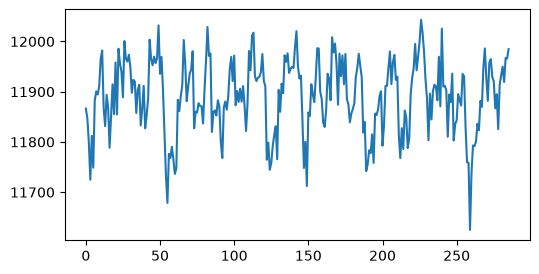

In [14]:
# Plot a single time series
fig = plt.figure(figsize=(6,3))
plt.plot(data[13,30,42]);

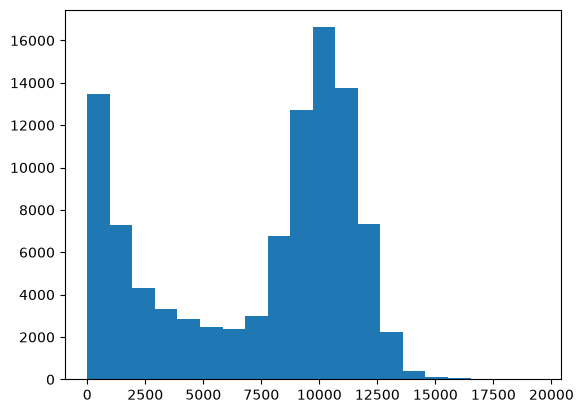

In [15]:
# Plot a histogram of all the values different from zero at a given time point
t = 40
plt.hist(data[:,:,:,t][data[:,:,:,t]>0].flatten(), bins=20);

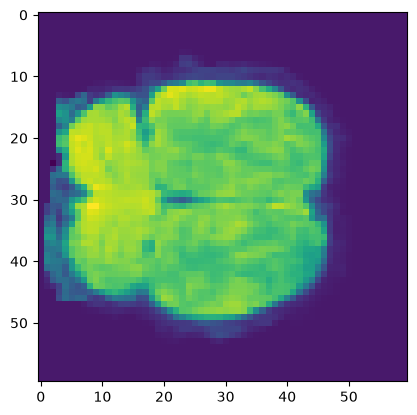

In [16]:
# Plot some slices with matplotlib
"""""
Name of the cuts:
- fixed x: Saggital, view from the side of the brain
- fixed y: Coronal, view from the front of the brain
- fixed z: Axial, view from the top of the brain

"""""
t = 40
slice = data[:,20,:,t]
plt.imshow(slice)

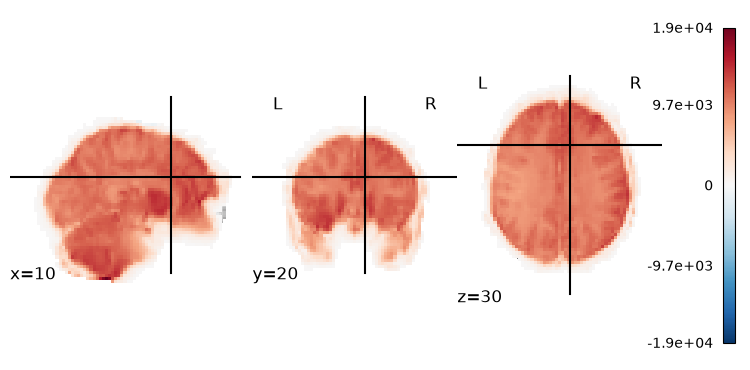

In [17]:
### Plot some slices with nibabel
### The plot_stat_map() function (and all the other plotting methods from nilearn) needs the fmri image in nifti format
# Chose a time slice
t = 40
slice = data[:,:,:,t]
slice_nifti = nib.Nifti1Image(slice, affine) # The numpy slice as to be convered back to nifti format
# plotting.plot_stat_map(slice_nifti, display_mode='ortho')
plotting.plot_stat_map(slice_nifti, cut_coords=(10,20,30), display_mode='ortho')

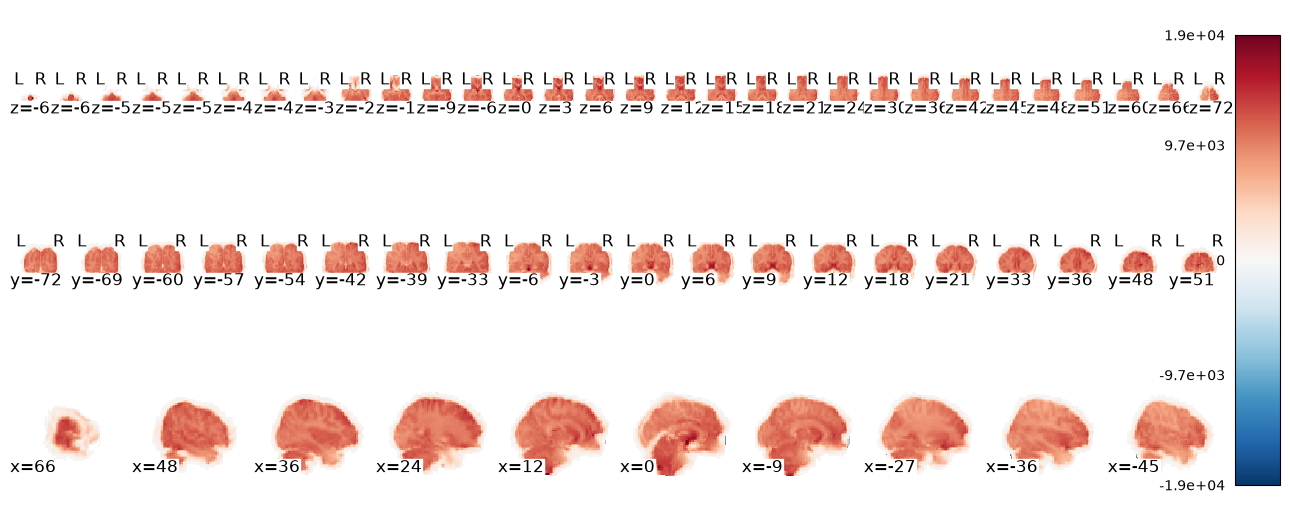

In [18]:
plotting.plot_stat_map(slice_nifti, cut_coords=(10,20,30), display_mode='mosaic')

# Many kinds of plotting style

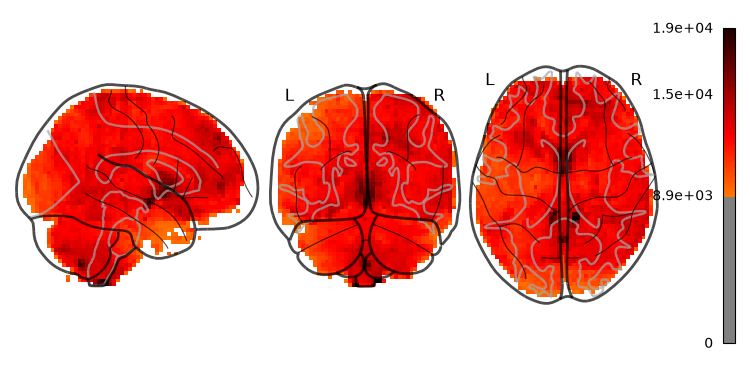

In [19]:
# Glass brain
plotting.plot_glass_brain(slice_nifti)

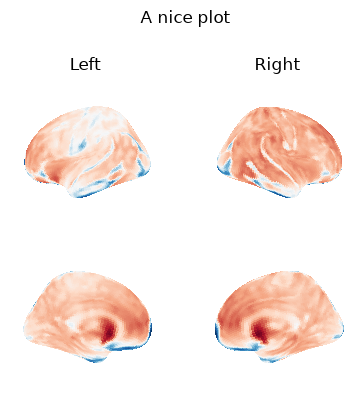

In [21]:
### Projection over cortical surface ###
fsaverage = datasets.fetch_surf_fsaverage()
texture_left = surface.vol_to_surf(slice_nifti, fsaverage.pial_left)
texture_right = surface.vol_to_surf(slice_nifti, fsaverage.pial_right)

thresh = 0.2 # Threshold for the brain plots

fig, axs = plt.subplots(2,2, subplot_kw={'projection': '3d'}, figsize=(4,4))
# Left hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                       title='Left', view='lateral',colorbar=False, threshold=thresh, axes=axs[0][0])
# Right hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right, bg_map=fsaverage.sulc_right,hemi='right',
                       title='Right', view='lateral', colorbar=False, threshold=thresh, axes=axs[0][1])
# Right hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                            view='medial', colorbar=False, threshold=thresh, axes=axs[1][0])
plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right, bg_map=fsaverage.sulc_right,hemi='right',
                            view='medial', colorbar=False, threshold=thresh, axes=axs[1][1])
fig.suptitle('A nice plot', x=0.51, y=1)
plt.tight_layout()
plotting.show()

# Atlas

Glasser paper: https://www.nature.com/articles/nature18933 \
Schaefer paper: https://academic.oup.com/cercor/article/28/9/3095/3978804

In [ ]:
main_path = '/content/'
file_name = 'glasser_atlas.nii.gz'
file_name_labels = 'glasser_labels.csv'

# path = main_path + 'schaefer_plus_TIAN_SC_LGN_SLEEPresamp.nii.gz'
# path_lab = main_path + 'schaefer_plus_TIAN_SC_LGN.csv'

atlas_ = nib.load(main_path+file_name)
atlas = atlas_.get_fdata()
atlas_header = atlas_.header
atlas_affine = atlas_.affine
atlas_labels = pd.read_csv(main_path+file_name_labels, delimiter=',')
print(atlas.shape)

(60, 72, 60)


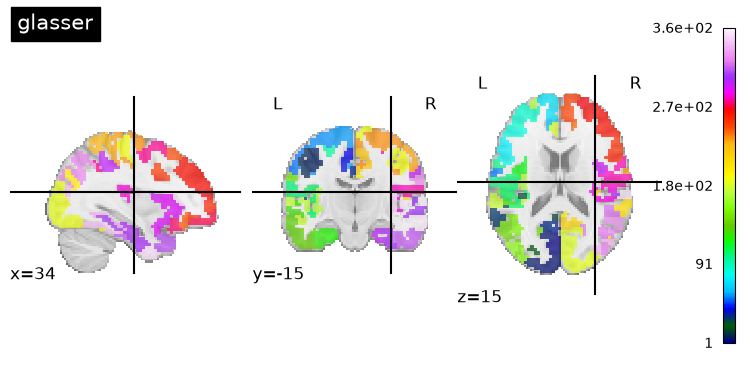

In [13]:
# Plot the atlas
plotting.plot_roi(atlas_, title='glasser', display_mode='ortho')

In [14]:
atlas_labels

,regionName,regionLongName,regionIdLabel,LR,region,Lobe,cortex,regionID,Cortex_ID,x-cog,y-cog,z-cog,volmm
0,V1_L,Primary_Visual_Cortex_L,1_L,L,V1,Occ,Primary_Visual,1,1,100.491589,41.138901,71.637040,6717
1,MST_L,Medial_Superior_Temporal_Area_L,2_L,L,MST,Occ,MT+_Complex_and_Neighboring_Visual_Areas,2,5,132.416667,58.901786,82.059524,336
2,V6_L,Sixth_Visual_Area_L,3_L,L,V6,Occ,Dorsal_Stream_Visual,3,3,104.543112,44.481665,103.916749,1009
3,V2_L,Second_Visual_Area_L,4_L,L,V2,Occ,Early_Visual,4,2,102.236656,44.064791,74.401125,6220
4,V3_L,Third_Visual_Area_L,5_L,L,V3,Occ,Early_Visual,5,2,107.926111,40.632159,76.961153,4994
...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,STSva_R,Area_STSv_anterior_R,376_R,R,STSva,Temp,Auditory_Association,376,11,32.924419,117.527907,54.337791,1720
356,TE1m_R,Area_TE1_Middle_R,377_R,R,TE1m,Temp,Lateral_Temporal,377,14,26.146605,102.236497,53.246528,2592
357,PI_R,Para-Insular_Area_R,378_R,R,PI,Temp,Insular_and_Frontal_Opercular,378,12,47.013363,123.157016,57.926503,898
358,a32pr_R,Area_anterior_32_prime_R,379_R,R,a32pr,Fr,Anterior_Cingulate_and_Medial_Prefrontal,379,19,81.723096,153.990326,102.516324,827


In [15]:
atlas_labels['cortex'].unique()

<StringArray>
[                          'Primary_Visual',
 'MT+_Complex_and_Neighboring_Visual_Areas',
                     'Dorsal_Stream_Visual',
                             'Early_Visual',
                    'Ventral_Stream_Visual',
                  'Somatosensory_and_Motor',
                                 'Premotor',
                      'Posterior_Cingulate',
                           'Early_Auditory',
       'Temporo-Parieto_Occipital_Junction',
                  'Dorsolateral_Prefrontal',
       'Temporo-Parieto-Occipital_Junction',
                        'Superior_Parietal',
    'Paracentral_Lobular_and_Mid_Cingulate',
 'Anterior_Cingulate_and_Medial_Prefrontal',
                'Orbital_and_Polar_Frontal',
                         'Inferior_Frontal',
                      'Posterior_Opercular',
            'Insular_and_Frontal_Opercular',
                     'Auditory_Association',
                        'Inferior_Parietal',
                          'Medial_Tempora

# Some preprocessing?

Example of a preprocessing pipeline:

1. Motion correction (via FSL or similar)
2. Spatial smoothing
3. Create Brain mask to exclude non-brain voxels
4. Temporal filtering
5. Registration and normalization according to a standard space (e.g. MNI)

In [ ]:
path = '/content/subj_zero_rest.nii.gz'
data_ = nib.load(path)
data = data_.get_fdata()

2. Spatial smoothing. \
The spatial smoothing applied thorugh the nilearn function nilearn.image.smooth_img applies a Gaussian filter along the three spatial dimensions of the fMRI volume. The spatial smoothing consists in a Gaussian weighted average across neighbouring voxels, separately at each time point. 

Text(0.5, 1.0, 'unsmoothed')

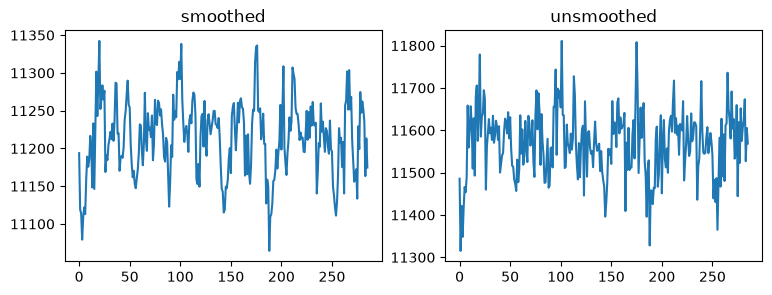

In [ ]:
# 2. Spatial smoothing
from nilearn.image import smooth_img
smoothed_data_ = smooth_img(data_, fwhm=6)  # FWHM: full width at half maximum (in mm)
smoothed_data = smoothed_data_.get_fdata()

# Visualize some voxels
x = 40
y = 30
z = 20
voxel_ts = data[x, y, z, :] # time series of the single voxel
smooth_voxel_ts = smoothed_data[x, y, z, :]
fig,axs = plt.subplots(1,2, figsize=(9,3))
axs[0].plot(smooth_voxel_ts, alpha=1)
axs[0].set_title('smoothed')
axs[1].plot(voxel_ts, alpha=1)
axs[1].set_title('unsmoothed')

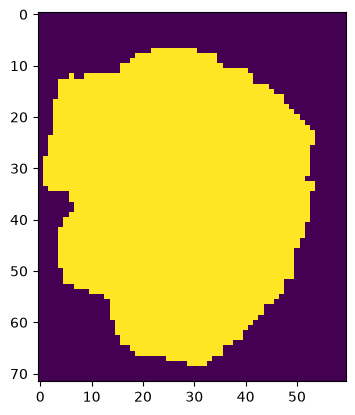

In [10]:
# 3. Create a brain mask
# Dummy masking
brain_mask = np.zeros(data.shape[0:3])
brain_mask[np.where(data.mean(axis=-1)>=20)] =1 # Take all the voxels that are on average greater than zero over time
mask_cord = np.where(brain_mask==1) # Coordinates of all the voxel within the brain mask

slice = brain_mask[20,:,:]
plt.imshow(slice)

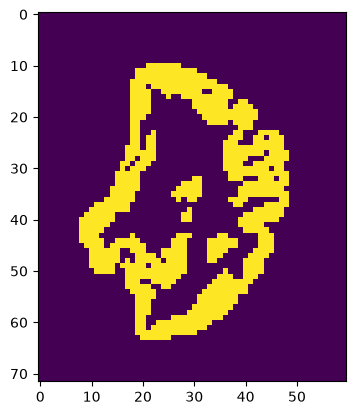

In [19]:
# 3. Create a brain mask
# Atlas masking

# Define a mask from the atlas
brain_mask = np.zeros(atlas.shape)
brain_mask[np.where(atlas!=0)]=1

slice = brain_mask[19,:,:]
plt.imshow(slice)

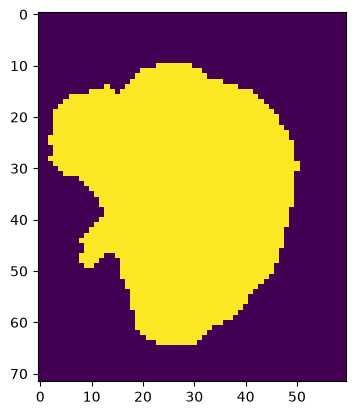

In [21]:
# 3. Create a brain mask
# nilearn masking
from nilearn.masking import compute_epi_mask, apply_mask
brain_mask_ = compute_epi_mask(data_)
brain_mask = brain_mask_.get_fdata()

slice = brain_mask[20,:,:]
plt.imshow(slice)

masked_data = apply_mask(data_, brain_mask_)

4. Time filtering \
Bandpass filter 

100%|██████████| 5/5 [00:00<00:00, 136.01it/s]


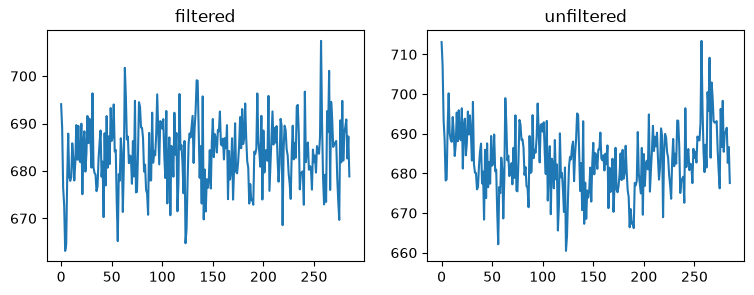

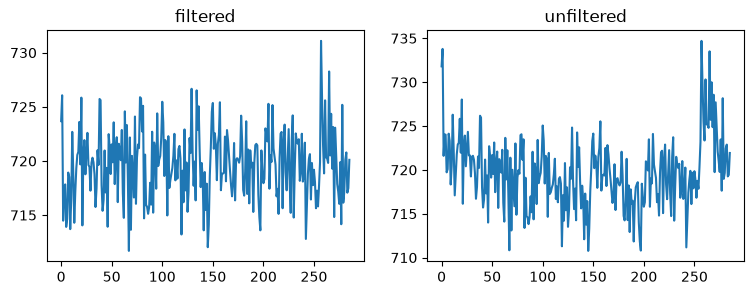

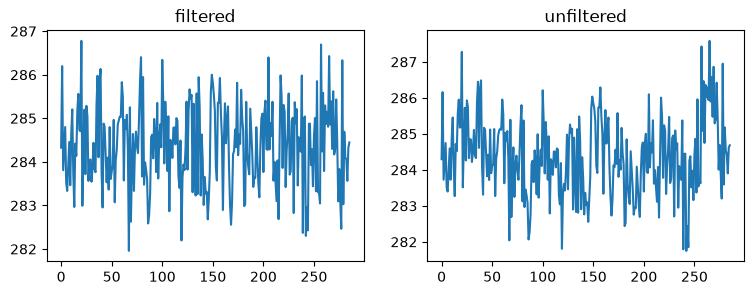

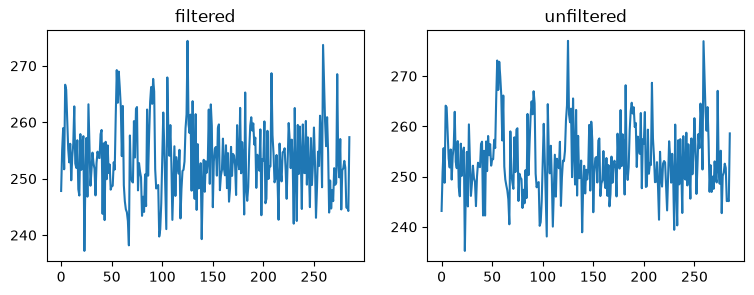

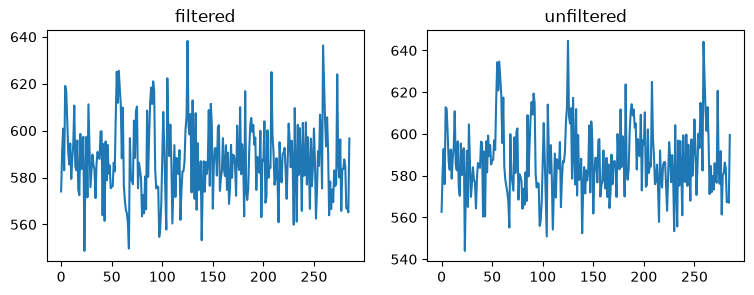

In [ ]:
# 4. Time filtering
from nitime.timeseries import TimeSeries
from nitime.analysis import FilterAnalyzer

n_voxels = np.prod(data.shape[:-1])

# An example of filtering with a bandpass filter
sub_filtered = np.copy(data)
TR = data_.header.get_zooms()[3]
for v in tqdm(range(15,20)): # some example voxels
    voxel_ts = data[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] # time series of the single voxel
    T = TimeSeries(voxel_ts.T, sampling_interval=TR)
    F = FilterAnalyzer(T, ub=0.25, lb=0.01) # ub: upper bound [Hz]; lb :lower bound [Hz]
    tmp_TC_filt = F.filtered_boxcar.data
    tmp_TC_filt = tmp_TC_filt.T
    sub_filtered[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] = tmp_TC_filt
    fig,axs = plt.subplots(1,2, figsize=(9,3))
    axs[0].plot(tmp_TC_filt, alpha=1)
    axs[0].set_title('filtered')
    axs[1].plot(voxel_ts, alpha=1)
    axs[1].set_title('unfiltered')

# Introduction to EEG data in python

In [29]:
! pip install mne

   ---------------------------------------- 0.0/7.7 MB ? eta -:--:--
   ---------------------------------------- 7.7/7.7 MB 47.5 MB/s eta 0:00:00


In [31]:
import mne

In [ ]:
files_dict = {'eeg_vhdr' : ('subj_0001.vhdr','1oKyrq9a4ylCDo4JRNb_yANVoc-EUOYhe'),
              'eeg_vmrk':   ('subj_0001.vmrk','1VPT5SrDvDmTbCfsiGzKaZptIX-nL701g'),
              'eeg_eeg': ('subj_0001.eeg', '1m6p8D5o6POFm8WasqI_3_5h03T4LI0gx')}

In [ ]:
for key in files_dict.keys():
  download_from_drive(key)

Extracting parameters from ../content/subj_0001.vhdr...
Setting channel info structure...
Reading 0 ... 4183639  =      0.000 ...  4183.639 secs...


C:\Users\alebo\AppData\Local\Temp\ipykernel_15504\32872191.py:8: RuntimeWarning: Online software filter detected. Using software filter settings and ignoring hardware values
  raw = mne.io.read_raw_brainvision(file_path, preload=True)


<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T7, T8, P7, ...
 chs: 62 EEG
 custom_ref_applied: False
 dig: 65 items (3 Cardinal, 62 EEG)
 highpass: 0.0 Hz
 lowpass: 500.0 Hz
 meas_date: 2024-04-03 11:53:07 UTC
 nchan: 62
 projs: []
 sfreq: 1000.0 Hz
>
Using matplotlib as 2D backend.
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


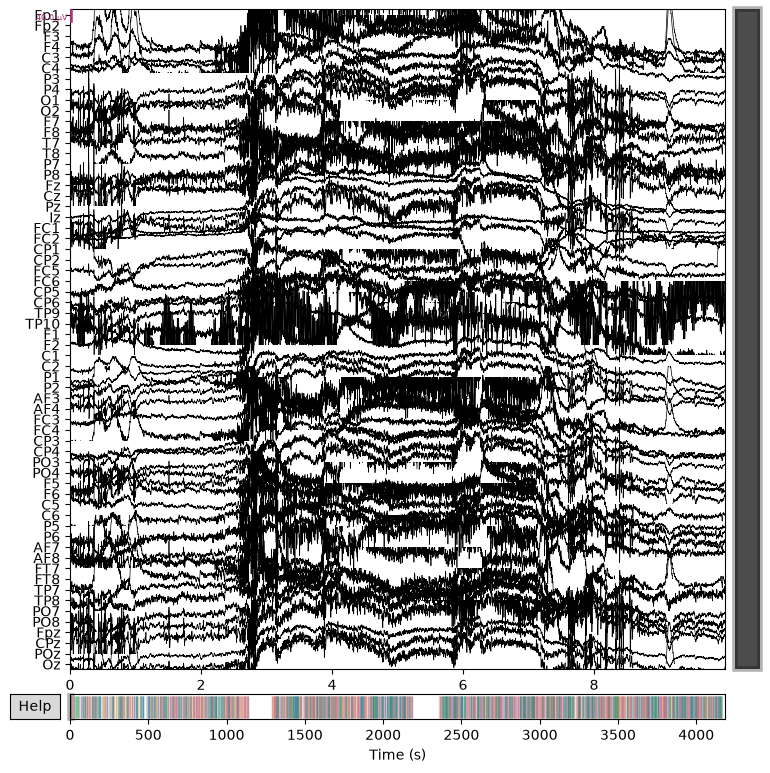

In [ ]:
# Path to the .vhdr file (make sure all the three files are in the same directory)


file_path = '/content/subj_0001.vhdr' # The .vhdr file points to the others

# Load the EEG data from the .vhdr file
raw = mne.io.read_raw_brainvision(file_path, preload=True)

# Print general informations about the loaded data
print(raw.info)

# Plot the raw EEG data
raw.plot(n_channels=62);

In [33]:
sfreq = raw.info['sfreq']
print(f"Sampling frequency: {sfreq} Hz")

Sampling frequency: 1000.0 Hz


In [34]:
# Plot the names of all the electrodes
for ch_name, ch_type in zip(raw.info['ch_names'], raw.get_channel_types()):
    print(f"Channel: {ch_name}, Type: {ch_type}")

Channel: Fp1, Type: eeg
Channel: Fp2, Type: eeg
Channel: F3, Type: eeg
Channel: F4, Type: eeg
Channel: C3, Type: eeg
Channel: C4, Type: eeg
Channel: P3, Type: eeg
Channel: P4, Type: eeg
Channel: O1, Type: eeg
Channel: O2, Type: eeg
Channel: F7, Type: eeg
Channel: F8, Type: eeg
Channel: T7, Type: eeg
Channel: T8, Type: eeg
Channel: P7, Type: eeg
Channel: P8, Type: eeg
Channel: Fz, Type: eeg
Channel: Cz, Type: eeg
Channel: Pz, Type: eeg
Channel: Iz, Type: eeg
Channel: FC1, Type: eeg
Channel: FC2, Type: eeg
Channel: CP1, Type: eeg
Channel: CP2, Type: eeg
Channel: FC5, Type: eeg
Channel: FC6, Type: eeg
Channel: CP5, Type: eeg
Channel: CP6, Type: eeg
Channel: TP9, Type: eeg
Channel: TP10, Type: eeg
Channel: F1, Type: eeg
Channel: F2, Type: eeg
Channel: C1, Type: eeg
Channel: C2, Type: eeg
Channel: P1, Type: eeg
Channel: P2, Type: eeg
Channel: AF3, Type: eeg
Channel: AF4, Type: eeg
Channel: FC3, Type: eeg
Channel: FC4, Type: eeg
Channel: CP3, Type: eeg
Channel: CP4, Type: eeg
Channel: PO3, T

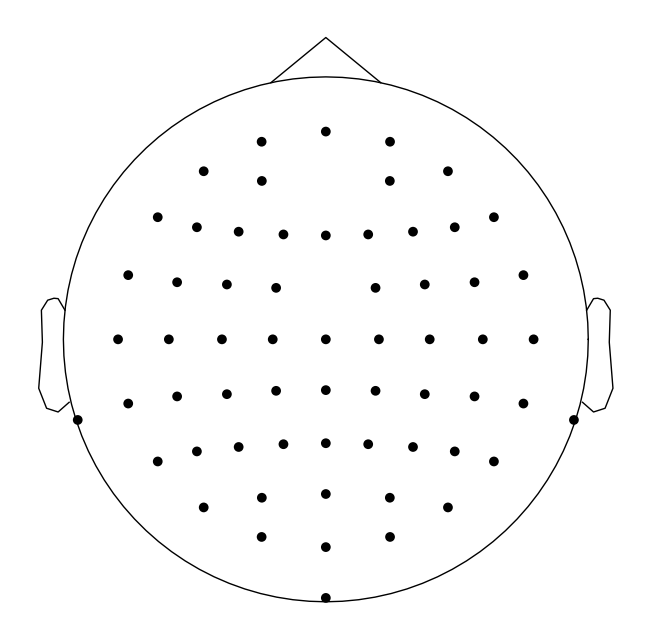

In [35]:
# Plot the montage, i.e. the location of the channels over the scalp
raw.plot_sensors(kind='topomap', sphere=(0, 0, 0, 0.12));
# raw.plot_sensors(kind='topomap');

In [36]:
# extract the data as a numpy array (channels x samples)
data, times = raw.get_data(return_times=True) # times in seconds

In [39]:
data.shape # channels x time points

(62, 4183640)

In [40]:
# Get the channels position
pos = mne.channels.layout._find_topomap_coords(raw.info, picks='eeg')

In [41]:
# Pick a time point, e.g., 1 seconds
time_point = 1.0  # in seconds

# Find index for the chosen time
idx = (np.abs(times - time_point)).argmin()

# Extract values for that time point
values = data[:, idx]

In [42]:
values.shape

(62,)

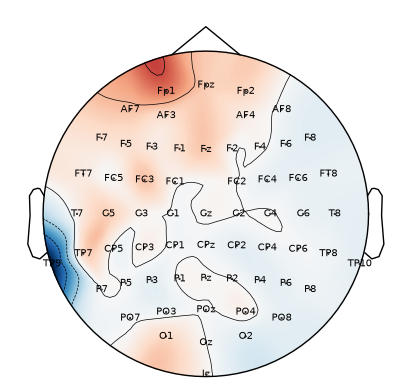

In [43]:
mne.viz.plot_topomap(values,
                     pos,
                     names=raw.info['ch_names'],
                     sphere=(0, 0, 0, 0.12),
                     size=4);

In [44]:
# Some basic preprocessing - bandpass filtering
raw_filtered = raw.copy().filter(l_freq=1.0, h_freq=40.0)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 3301 samples (3.301 s)



For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


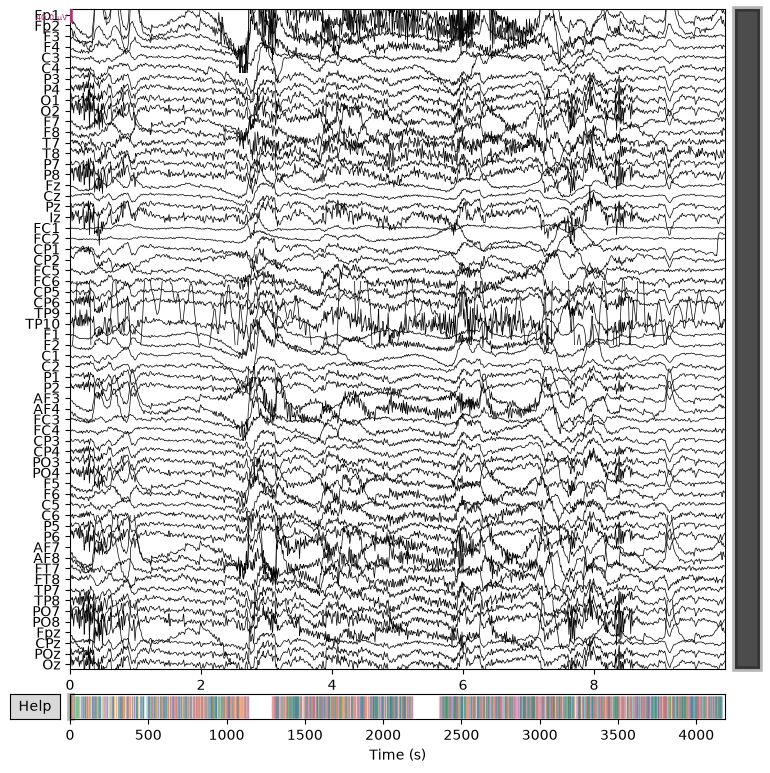

In [45]:
raw_filtered.plot(n_channels=62);

In [46]:
# Some basic preprocessing - ICA
ica = mne.preprocessing.ICA(n_components=20, random_state=42, max_iter='auto')
ica.fit(raw_filtered)


Use rng= instead of random_state= in new code
Fitting ICA to data using 62 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 176.1s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,58 iterations on raw data (4183640 samples)
ICA components,20
Available PCA components,62
Channel types,eeg
ICA components marked for exclusion,—


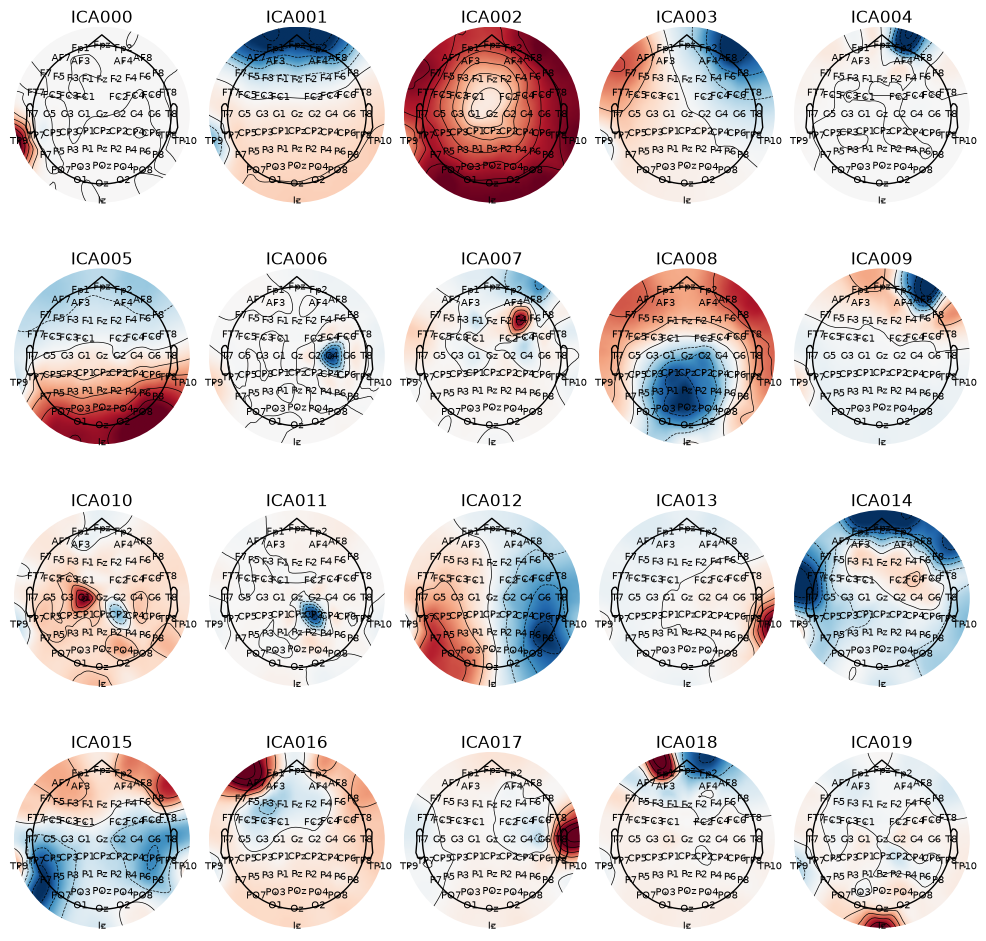

In [47]:
ica.plot_components(show_names=True);

Creating RawArray with float64 data, n_channels=20, n_times=4183640
    Range : 0 ... 4183639 =      0.000 ...  4183.639 secs
Ready.
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


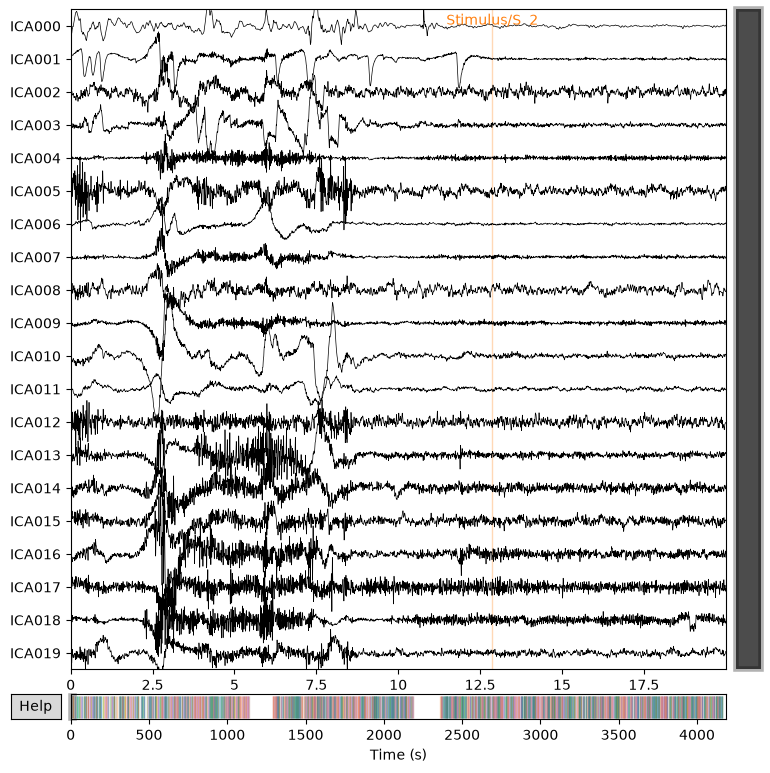

In [49]:
ica.plot_sources(raw_filtered, picks=[i for i in range(20)]);
# ica.plot_sources(raw_filtered, picks=[i for i in range(15,30)]);

Effective window size : 2.048 (s)


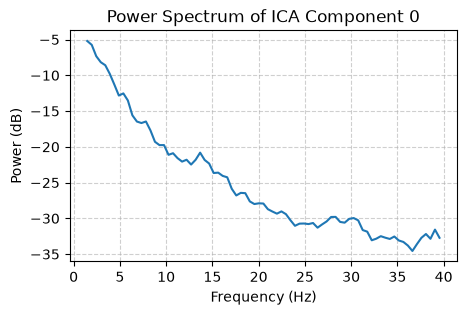

Effective window size : 2.048 (s)


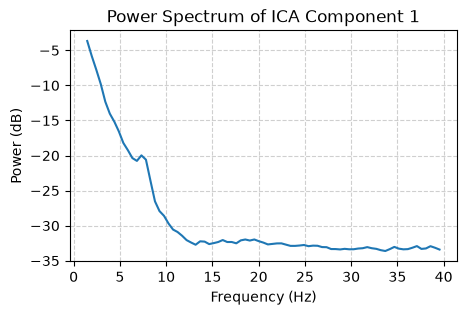

Effective window size : 2.048 (s)


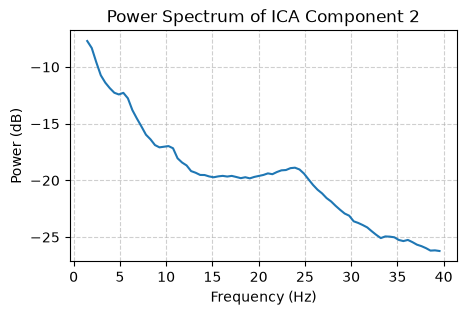

Effective window size : 2.048 (s)


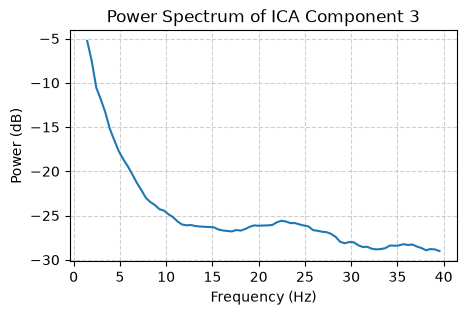

Effective window size : 2.048 (s)


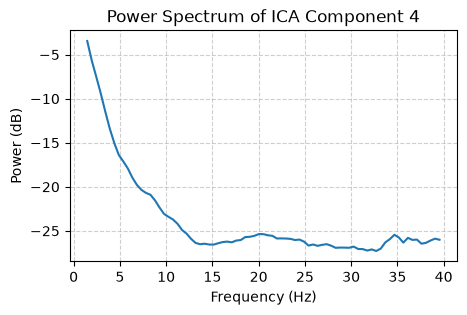

Effective window size : 2.048 (s)


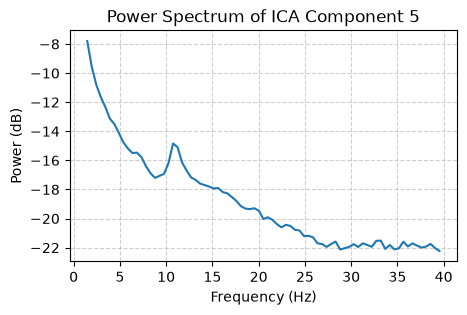

Effective window size : 2.048 (s)


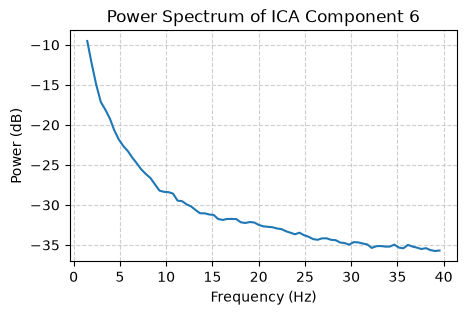

Effective window size : 2.048 (s)


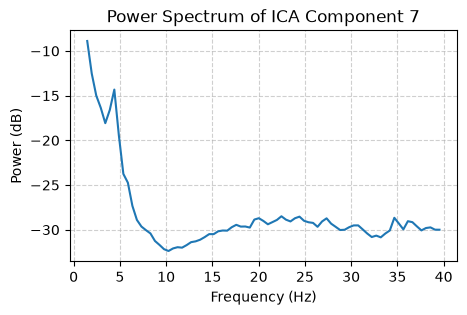

Effective window size : 2.048 (s)


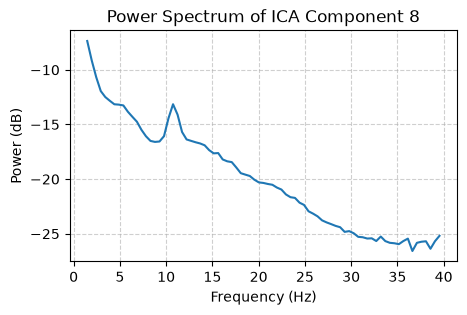

Effective window size : 2.048 (s)


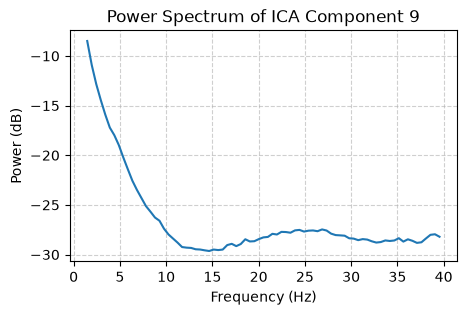

Effective window size : 2.048 (s)


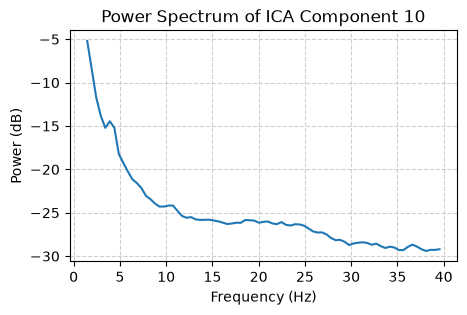

Effective window size : 2.048 (s)


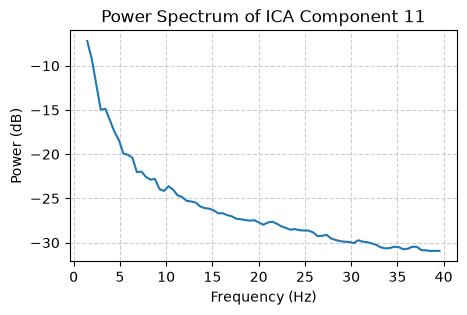

Effective window size : 2.048 (s)


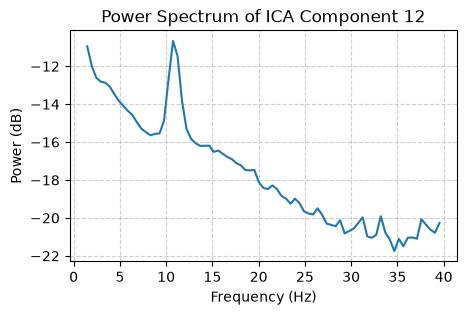

Effective window size : 2.048 (s)


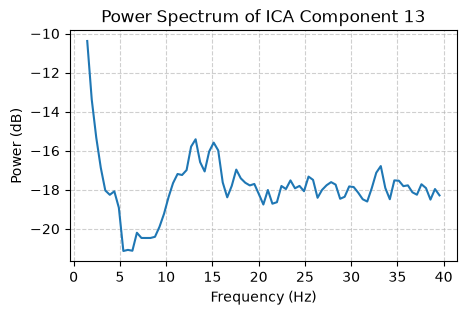

Effective window size : 2.048 (s)


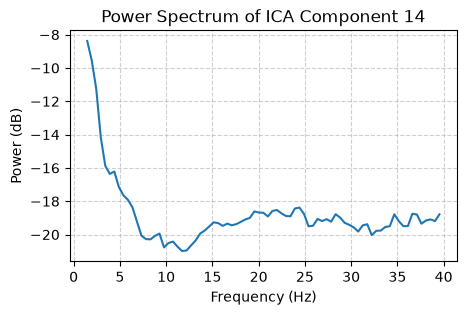

Effective window size : 2.048 (s)


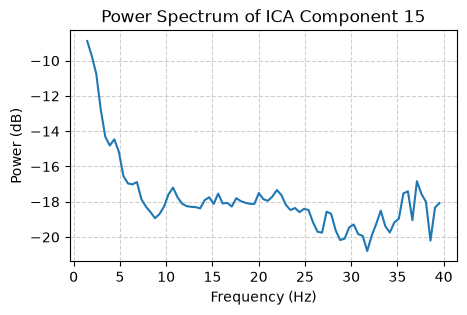

Effective window size : 2.048 (s)


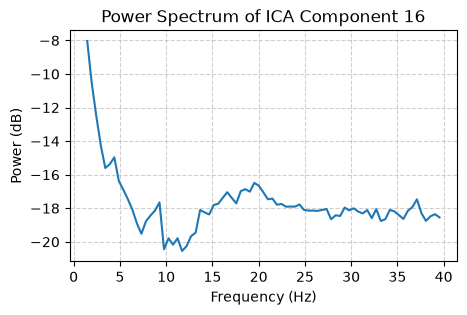

Effective window size : 2.048 (s)


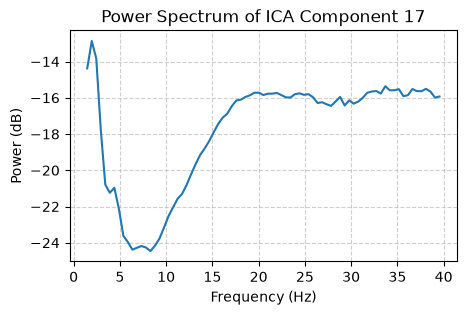

Effective window size : 2.048 (s)


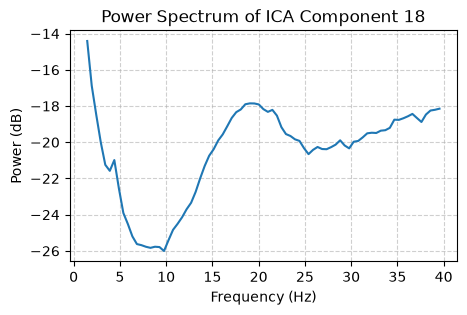

Effective window size : 2.048 (s)


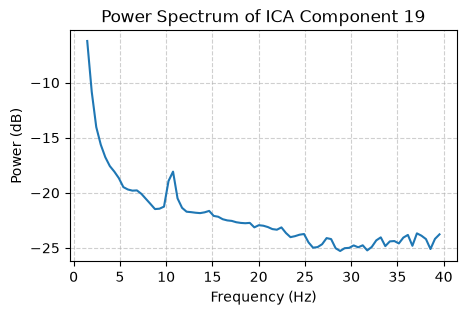

In [50]:
### Print Power spectrum of ICA decomposition ###
sources = ica.get_sources(raw_filtered)

# 5. Plot the power spectrum for each ICA component
n_components = ica.n_components_

# Loop through each ICA component
for i in range(n_components):
    # Extract the signal of component i
    component_data = sources.get_data(picks=[i])  # Get data for the i-th ICA component

    # Compute the power spectral density (PSD) of the component
    psd, freqs = mne.time_frequency.psd_array_welch(
        component_data[0],  # Extract the first row (since it's a single component)
        sfreq=raw.info['sfreq'],  # Sampling frequency from the raw data
        fmin=1, fmax=40,  # Focus on the 1-40 Hz range
        n_fft=2048  # Length of FFT (controls frequency resolution)
    )

    # Plot the power spectrum of the component
    plt.figure(figsize=(5, 3))
    plt.plot(freqs, 10 * np.log10(psd), label=f'Component {i}')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Power (dB)')
    plt.title(f'Power Spectrum of ICA Component {i}')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()